# Road Accident Severity Prediction — End-to-End ML Pipeline

Dataset: **India Road Accident Dataset – Predictive Analysis** (Kaggle, khushikyad001)

This notebook follows:
1. Title & Objective
2. Import Libraries
3. Load Dataset
4. Dataset Shape
5. Head & Tail
6. Dataset Information
7. Descriptive Statistics
8. Missing Value Analysis
9. Duplicate Analysis
10. Unique Values
11. Target Variable Analysis
12. Univariate Analysis
13. Bivariate Analysis
14. Correlation Analysis
15. Key Observations
16. Conclusion
17. Next Steps (Optional)


In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

import joblib
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)
print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
# Path to the downloaded Kaggle dataset
csv_path = '../data/raw/accident_prediction_india.csv'

if not os.path.exists(csv_path):
    raise FileNotFoundError(
        f"Kaggle dataset not found at '{csv_path}'. "
        "Please download the dataset from: "
        "https://www.kaggle.com/datasets/khushikyad001/india-road-accident-dataset-predictive-analysis "
        "and place the CSV file named 'accident_prediction_india.csv' inside the '../data/' folder."
    )

df = pd.read_csv(csv_path)
print("Dataset loaded successfully!")
print(f"Raw dataset dimensions: {df.shape[0]} rows, {df.shape[1]} columns\n")

# Normalize column names to lowercase snake_case
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Rename Kaggle columns to match the standard PRD schema
rename_dict = {
    'state_name': 'state',
    'city_name': 'city',
    'accident_severity': 'severity',
    'number_of_vehicles_involved': 'num_vehicles',
    'vehicle_type_involved': 'vehicle_type',
    'weather_conditions': 'weather',
    'speed_limits': 'speed_limit',
    'alcohol_involvement': 'alcohol_involved',
    'gender': 'driver_gender',
    'time_of_day': 'time'
}
df = df.rename(columns=rename_dict)

print("Normalized & Schema-Mapped Columns:")
print(list(df.columns))

Dataset loaded successfully!
Raw dataset dimensions: 3000 rows, 22 columns

Normalized & Schema-Mapped Columns:
['state', 'city', 'year', 'month', 'day_of_week', 'time', 'severity', 'num_vehicles', 'vehicle_type', 'number_of_casualties', 'number_of_fatalities', 'weather', 'road_type', 'road_condition', 'lighting_conditions', 'traffic_control_presence', 'speed_limit_(km/h)', 'driver_age', 'driver_gender', 'driver_license_status', 'alcohol_involved', 'accident_location_details']


In [7]:
print("Dataset Shape")

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Dataset Shape
Rows    : 3000
Columns : 22


In [8]:
df.head()

,state,city,year,month,day_of_week,time,severity,num_vehicles,vehicle_type,number_of_casualties,number_of_fatalities,weather,road_type,road_condition,lighting_conditions,traffic_control_presence,speed_limit_(km/h),driver_age,driver_gender,driver_license_status,alcohol_involved,accident_location_details
0,Jammu and Kashmir,Unknown,2021,May,Monday,1:46,Serious,5,Cycle,0,4,Hazy,National Highway,Wet,Dark,Signs,61,66,Male,NaN,Yes,Curve
1,Uttar Pradesh,Lucknow,2018,January,Wednesday,21:30,Minor,5,Truck,5,4,Hazy,Urban Road,Dry,Dusk,Signs,92,60,Male,NaN,Yes,Straight Road
2,Chhattisgarh,Unknown,2023,May,Wednesday,5:37,Minor,5,Pedestrian,6,5,Foggy,National Highway,Under Construction,Dawn,Signs,120,26,Female,NaN,No,Bridge
3,Uttar Pradesh,Lucknow,2020,June,Saturday,0:31,Minor,3,Bus,10,5,Rainy,State Highway,Dry,Dark,Signals,76,34,Female,Valid,Yes,Straight Road
4,Sikkim,Unknown,2021,August,Thursday,11:21,Minor,5,Cycle,7,1,Foggy,Urban Road,Wet,Dusk,Signs,115,30,Male,NaN,No,Intersection


In [9]:
df.tail()

,state,city,year,month,day_of_week,time,severity,num_vehicles,vehicle_type,number_of_casualties,number_of_fatalities,weather,road_type,road_condition,lighting_conditions,traffic_control_presence,speed_limit_(km/h),driver_age,driver_gender,driver_license_status,alcohol_involved,accident_location_details
2995,Tamil Nadu,Chennai,2021,January,Sunday,1:15,Minor,5,Truck,4,3,Foggy,National Highway,Wet,Dark,Signs,74,43,Male,Expired,Yes,Intersection
2996,Uttarakhand,Unknown,2018,July,Sunday,10:12,Fatal,3,Car,3,0,Hazy,Urban Road,Under Construction,Daylight,NaN,86,23,Female,NaN,Yes,Intersection
2997,Meghalaya,Unknown,2021,January,Thursday,19:34,Minor,2,Two-Wheeler,8,5,Rainy,National Highway,Dry,Dark,Signs,47,57,Female,Valid,Yes,Intersection
2998,Meghalaya,Unknown,2023,June,Sunday,20:54,Fatal,1,Cycle,9,2,Stormy,Urban Road,Under Construction,Daylight,Signs,60,28,Female,Expired,Yes,Bridge
2999,Arunachal Pradesh,Unknown,2020,September,Monday,7:19,Fatal,5,Cycle,1,3,Hazy,National Highway,Under Construction,Daylight,NaN,40,66,Male,NaN,Yes,Bridge


In [10]:
print("Basic Information")
df.info()

Basic Information
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   state                      3000 non-null   str  
 1   city                       3000 non-null   str  
 2   year                       3000 non-null   int64
 3   month                      3000 non-null   str  
 4   day_of_week                3000 non-null   str  
 5   time                       3000 non-null   str  
 6   severity                   3000 non-null   str  
 7   num_vehicles               3000 non-null   int64
 8   vehicle_type               3000 non-null   str  
 9   number_of_casualties       3000 non-null   int64
 10  number_of_fatalities       3000 non-null   int64
 11  weather                    3000 non-null   str  
 12  road_type                  3000 non-null   str  
 13  road_condition             3000 non-null   str  
 14  lighting_conditio

In [11]:
print("\nDescriptive Statistics")
display(df.describe(include='all'))


Descriptive Statistics


,state,city,year,month,day_of_week,time,severity,num_vehicles,vehicle_type,number_of_casualties,number_of_fatalities,weather,road_type,road_condition,lighting_conditions,traffic_control_presence,speed_limit_(km/h),driver_age,driver_gender,driver_license_status,alcohol_involved,accident_location_details
count,3000,3000,3000.000000,3000,3000,3000,3000,3000.000000,3000,3000.000000,3000.000000,3000,3000,3000,3000,2284,3000.000000,3000.00000,3000,2025,3000,3000
unique,32,28,NaN,12,7,1263,3,NaN,7,NaN,NaN,5,4,4,4,3,NaN,NaN,2,2,2,4
top,Goa,Unknown,NaN,March,Wednesday,3:40,Minor,NaN,Truck,NaN,NaN,Rainy,State Highway,Under Construction,Dark,Signs,NaN,NaN,Female,Valid,Yes,Intersection
freq,109,2138,NaN,266,468,7,1034,NaN,449,NaN,NaN,631,771,778,763,812,NaN,NaN,1563,1057,1520,789
mean,NaN,NaN,2020.530000,NaN,NaN,NaN,NaN,2.996000,NaN,5.066000,2.455333,NaN,NaN,NaN,NaN,NaN,74.940667,44.17700,NaN,NaN,NaN,NaN
std,NaN,NaN,1.683858,NaN,NaN,NaN,NaN,1.428285,NaN,3.214097,1.717650,NaN,NaN,NaN,NaN,NaN,26.765088,15.40286,NaN,NaN,NaN,NaN
min,NaN,NaN,2018.000000,NaN,NaN,NaN,NaN,1.000000,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,30.000000,18.00000,NaN,NaN,NaN,NaN
25%,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN,2.000000,NaN,2.000000,1.000000,NaN,NaN,NaN,NaN,NaN,51.000000,31.00000,NaN,NaN,NaN,NaN
50%,NaN,NaN,2021.000000,NaN,NaN,NaN,NaN,3.000000,NaN,5.000000,2.000000,NaN,NaN,NaN,NaN,NaN,75.000000,45.00000,NaN,NaN,NaN,NaN
75%,NaN,NaN,2022.000000,NaN,NaN,NaN,NaN,4.000000,NaN,8.000000,4.000000,NaN,NaN,NaN,NaN,NaN,99.000000,57.00000,NaN,NaN,NaN,NaN


In [12]:
print("\nClass Counts of Target ('severity')")
print(df['severity'].value_counts())


Class Counts of Target ('severity')
severity
Minor      1034
Fatal       985
Serious     981
Name: count, dtype: int64


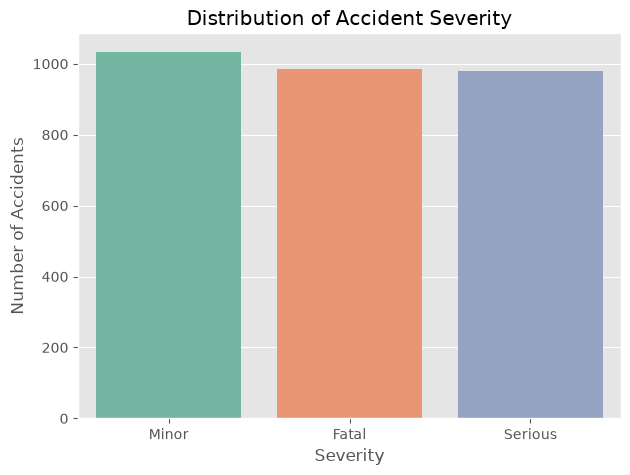

In [14]:
# Severity Distribution

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='severity',
    order=df['severity'].value_counts().index,
    palette='Set2'
)

plt.title("Distribution of Accident Severity")
plt.xlabel("Severity")
plt.ylabel("Number of Accidents")

plt.show()

In [15]:
severity_percentage = (
    df['severity']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Severity Percentage Distribution")
print(severity_percentage)

Severity Percentage Distribution
severity
Minor      34.47
Fatal      32.83
Serious    32.70
Name: proportion, dtype: float64


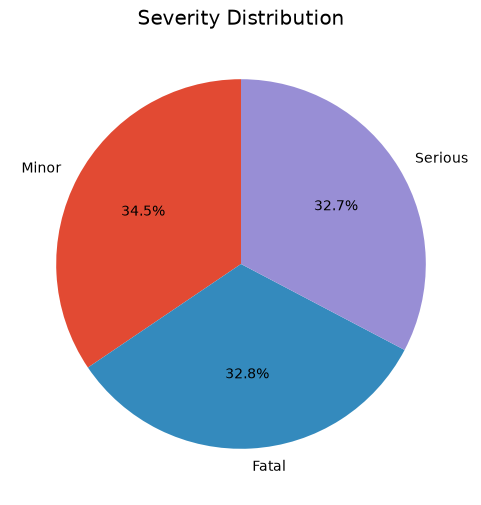

In [16]:
plt.figure(figsize=(6,6))

df['severity'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.ylabel("")
plt.title("Severity Distribution")

plt.show()

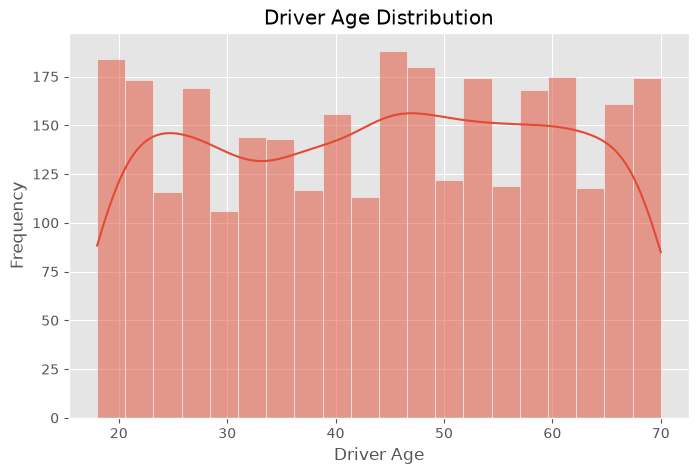

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['driver_age'],
    bins=20,
    kde=True
)

plt.title("Driver Age Distribution")
plt.xlabel("Driver Age")
plt.ylabel("Frequency")

plt.show()

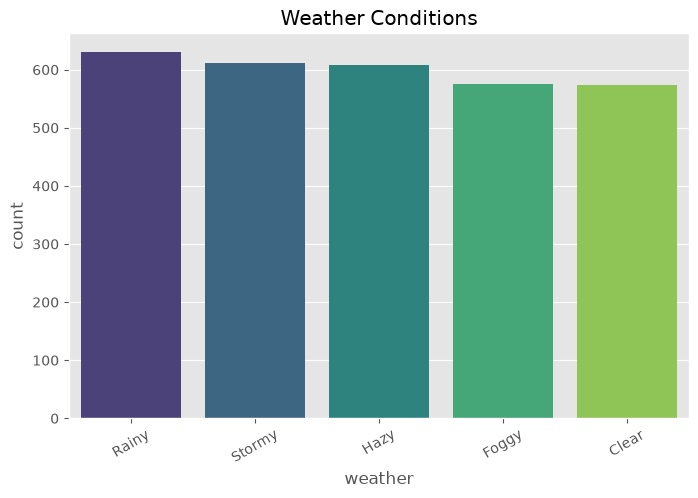

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='weather',
    order=df['weather'].value_counts().index,
    palette='viridis'
)

plt.xticks(rotation=30)

plt.title("Weather Conditions")

plt.show()

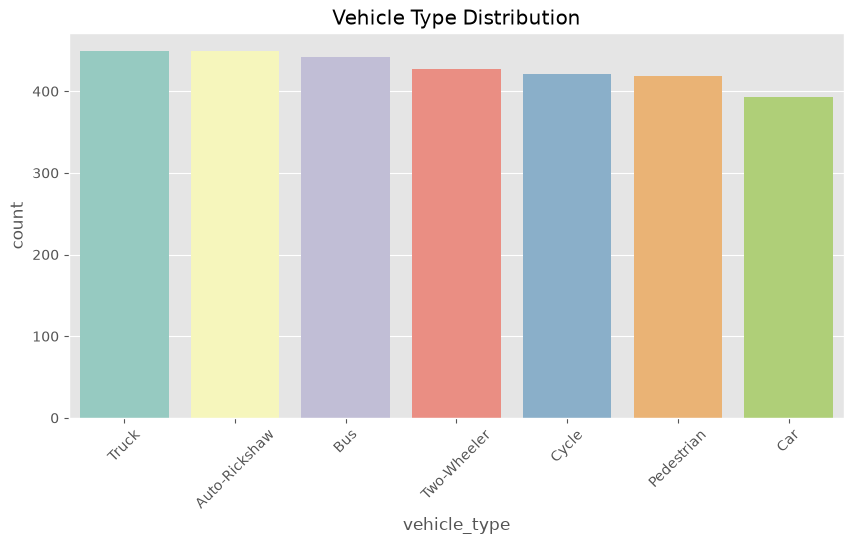

In [19]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='vehicle_type',
    order=df['vehicle_type'].value_counts().index,
    palette='Set3'
)

plt.xticks(rotation=45)

plt.title("Vehicle Type Distribution")

plt.show()

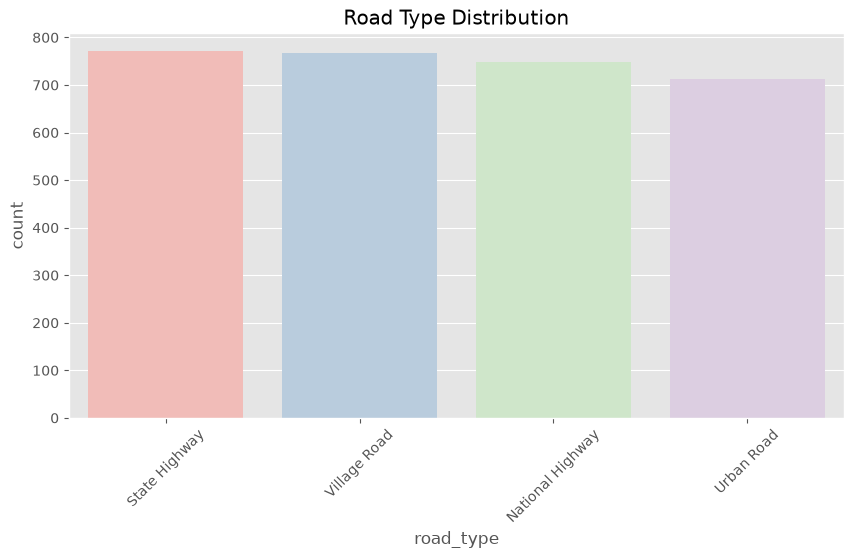

In [20]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='road_type',
    order=df['road_type'].value_counts().index,
    palette='Pastel1'
)

plt.xticks(rotation=45)

plt.title("Road Type Distribution")

plt.show()

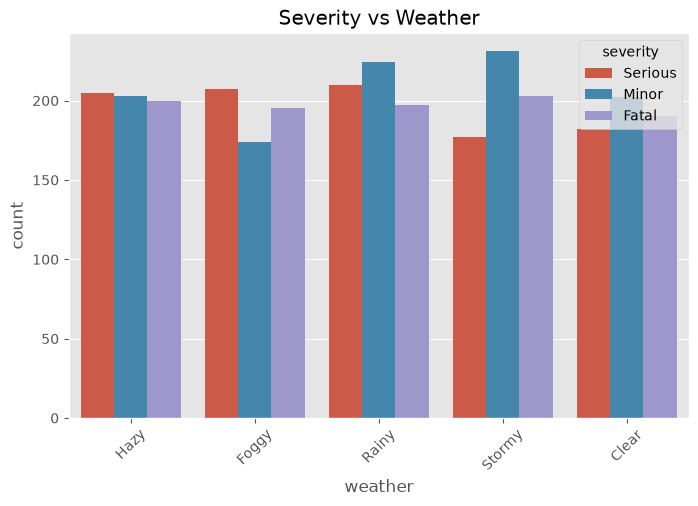

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='weather',
    hue='severity'
)

plt.title("Severity vs Weather")
plt.xticks(rotation=45)

plt.show()

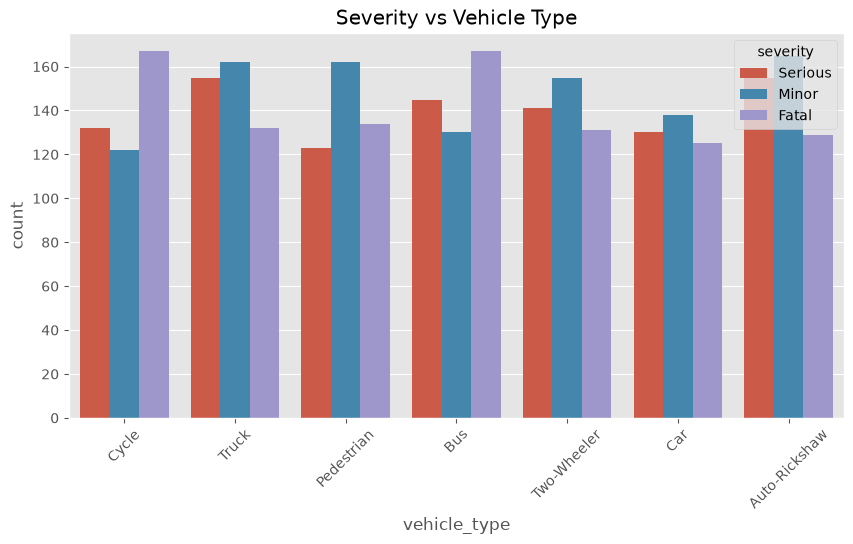

In [22]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='vehicle_type',
    hue='severity'
)

plt.title("Severity vs Vehicle Type")
plt.xticks(rotation=45)

plt.show()

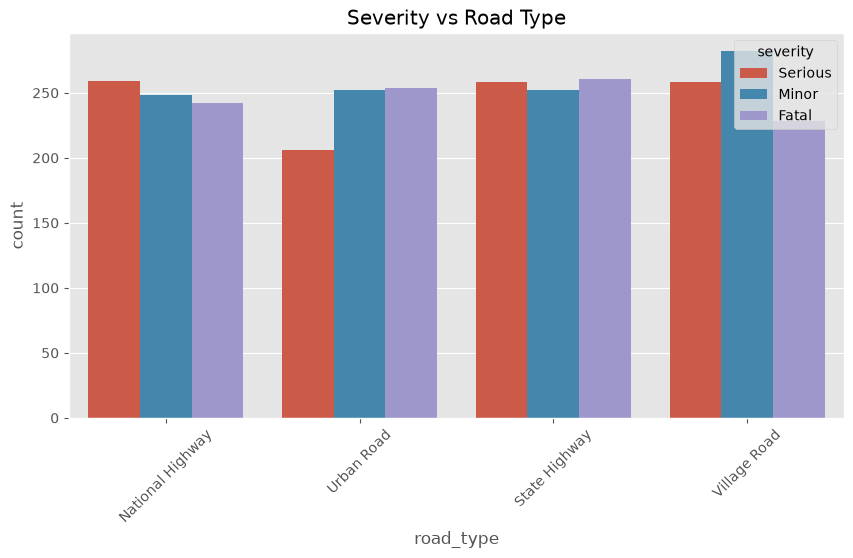

In [23]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='road_type',
    hue='severity'
)

plt.title("Severity vs Road Type")
plt.xticks(rotation=45)

plt.show()

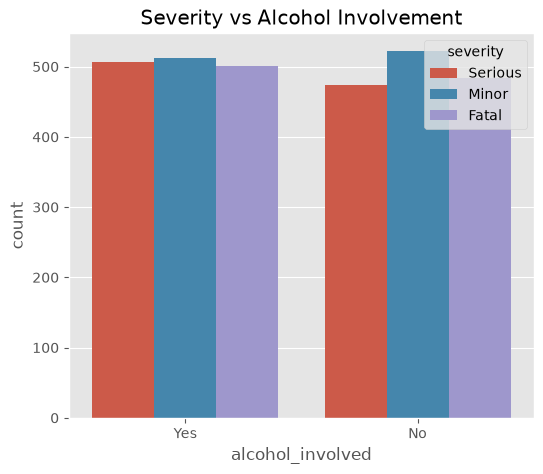

In [24]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='alcohol_involved',
    hue='severity'
)

plt.title("Severity vs Alcohol Involvement")

plt.show()

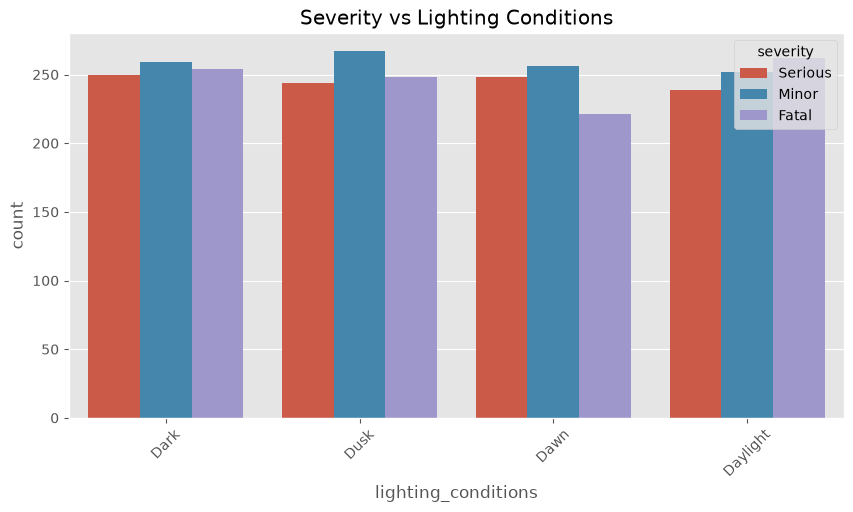

In [26]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='lighting_conditions',
    hue='severity'
)

plt.title("Severity vs Lighting Conditions")
plt.xticks(rotation=45)

plt.show()

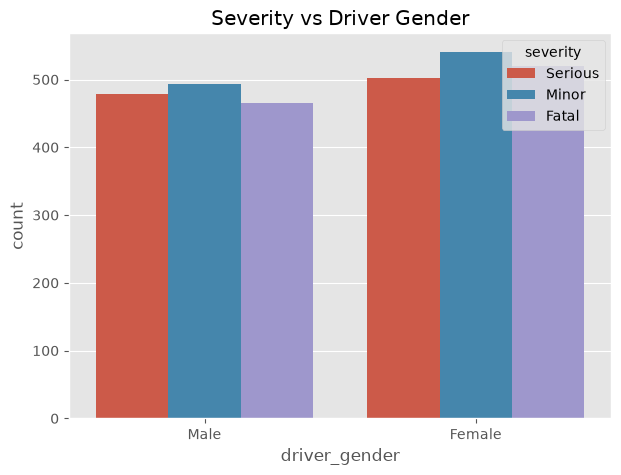

In [27]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='driver_gender',
    hue='severity'
)

plt.title("Severity vs Driver Gender")

plt.show()

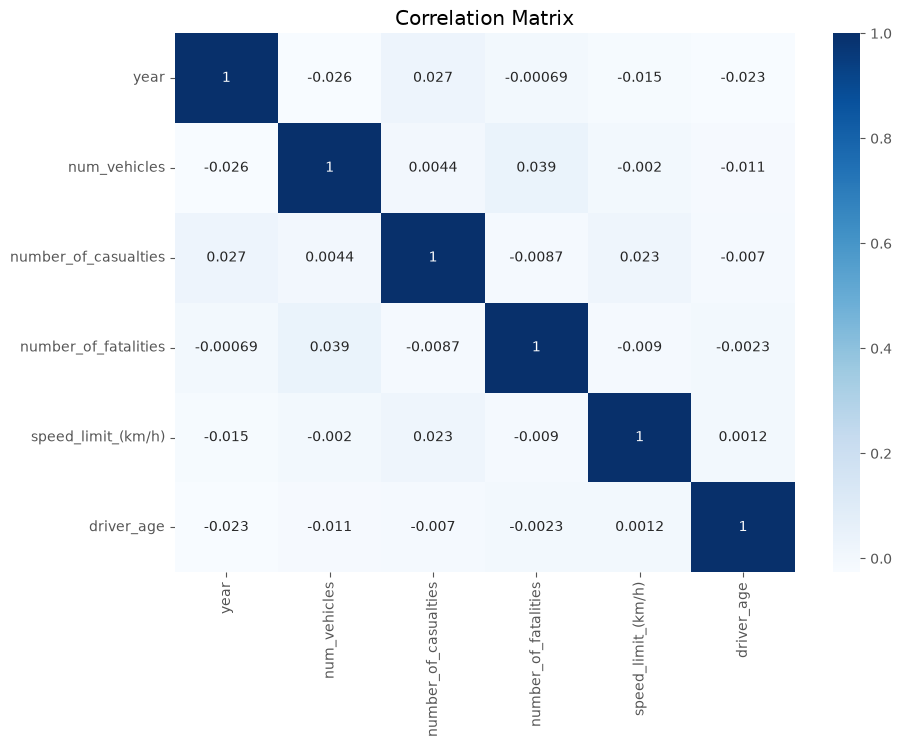

In [30]:
plt.figure(figsize=(10,7))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='Blues'
)

plt.title("Correlation Matrix")

plt.show()

# Key Observations

- The dataset contains XX accident records and XX features.
- Missing values are primarily found in ...
- The majority of accidents belong to the ... severity class.
- Weather conditions such as ... appear more frequently.
- Two-wheelers contribute significantly to accident records.
- Highway roads show a different severity distribution compared to city roads.
- Alcohol involvement is associated with higher accident severity.
- Driver age is concentrated between ... years.
- These observations guide the preprocessing and feature engineering steps in Notebook 02.

# Conclusion

The exploratory data analysis provided a comprehensive understanding of the road accident dataset.

### Summary

- The dataset contains accident records with demographic, environmental, road, and vehicle-related features.
- Missing values were identified in selected columns and will be handled during preprocessing.
- The target variable (severity) shows the distribution of accident severity classes.
- Features such as weather conditions, road type, lighting conditions, alcohol involvement, and vehicle type appear to influence accident severity.
- Numerical features were explored for their distributions and relationships.
- No preprocessing or feature engineering was performed in this notebook to preserve the original dataset for analysis.

The insights gained from this exploratory analysis will guide the preprocessing, feature engineering, and model development performed in **Notebook 02**.

# Next Steps

In the next notebook:

- Handle missing values
- Remove duplicate records
- Perform feature engineering
- Select relevant features
- Create the target variable
- Split the data into training and testing sets
- Build the preprocessing pipeline using ColumnTransformer
- Save the processed data for model training